<a href="https://colab.research.google.com/github/mundevaishnavi13/Artificial_Intelligence_Lab_SE_A_42/blob/master/ds8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

In [7]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (2).zip


In [10]:
import zipfile

# Unzip the archive (2).zip file to extract its contents
with zipfile.ZipFile('/content/archive (2).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/') # Extract to the current content directory

ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

In [11]:
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")
data = pd.merge(ratings, movies, on="movieId")
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [24]:
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

# Merge datasets
data = pd.merge(ratings, movies, on="movieId")

# Show first 5 rows
print("Dataset Preview:\n")
print(data.head())

Dataset Preview:

   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


In [25]:
# Convert genres into numerical values
data['genres'] = data['genres'].astype('category').cat.codes

# Select features and target
X = data[['userId', 'movieId', 'genres']]
y_reg = data['rating']

print("\nFeatures:\n", X.head())
print("\nTarget (Rating):\n", y_reg.head())


Features:
    userId  movieId  genres
0       1        1     351
1       1        3     732
2       1        6     260
3       1       47     937
4       1       50     790

Target (Rating):
 0    4.0
1    4.0
2    4.0
3    5.0
4    5.0
Name: rating, dtype: float64


Ratings Data:

0     4.0
1     4.0
2     4.0
3     5.0
4     5.0
5     3.0
6     5.0
7     4.0
8     5.0
9     5.0
10    5.0
11    5.0
12    3.0
13    5.0
14    4.0
15    5.0
16    3.0
17    3.0
18    5.0
19    4.0
Name: rating, dtype: float64

Rating Frequency:

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


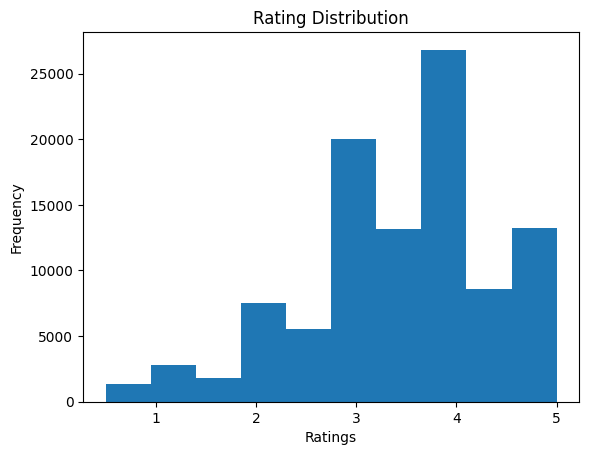

In [41]:
import matplotlib.pyplot as plt

# 🔹 Step 1: Show data used for graph
print("Ratings Data:\n")
print(data['rating'].head(20))   # show first 20 values

# Show frequency count (very useful)
print("\nRating Frequency:\n")
print(data['rating'].value_counts().sort_index())

# 🔹 Step 2: Plot histogram
plt.figure()
plt.hist(data['rating'], bins=10)

plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Frequency")

plt.show()

In [27]:
Split Dataset (Regression)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

In [42]:
Train Regression Model

reg = RandomForestRegressor()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

In [30]:
Evaluate Regression

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nRegression Evaluation:")
print("RMSE:", rmse)


Regression Evaluation:
RMSE: 0.964382372183288


In [31]:
Convert to Classification (High vs Low Rating)

# Convert rating into binary class
data['rating_class'] = np.where(data['rating'] >= 3.5, 1, 0)

y_cls = data['rating_class']

In [43]:
Split Dataset (Classification)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)

In [33]:
Train Classification Model

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred_cls = clf.predict(X_test)

In [34]:
Evaluate Classification

print("\nClassification Evaluation:")

print("Accuracy:", accuracy_score(y_test, y_pred_cls))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_cls))


Classification Evaluation:
Accuracy: 0.6619397064656882

Classification Report:

              precision    recall  f1-score   support

           0       0.57      0.51      0.54      7829
           1       0.71      0.76      0.73     12339

    accuracy                           0.66     20168
   macro avg       0.64      0.63      0.64     20168
weighted avg       0.66      0.66      0.66     20168



Confusion Matrix Data:

[[4015 3814]
 [3004 9335]]

Detailed Format:
True Negative (TN): 4015
False Positive (FP): 3814
False Negative (FN): 3004
True Positive (TP): 9335


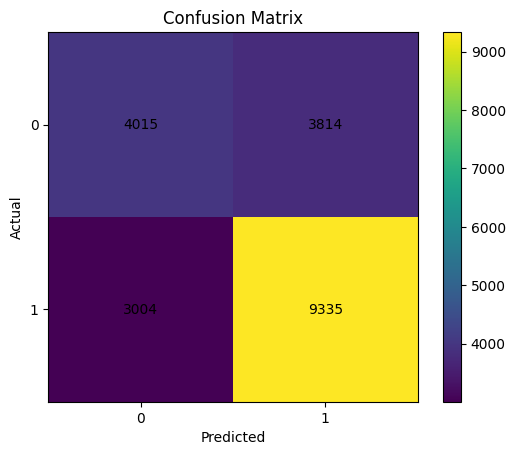

In [40]:
Confusion Matrix Plot

import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_cls)

# 🔹 Step 1: Show data in output
print("Confusion Matrix Data:\n")
print(cm)

# Optional: show in table format
print("\nDetailed Format:")
print(f"True Negative (TN): {cm[0][0]}")
print(f"False Positive (FP): {cm[0][1]}")
print(f"False Negative (FN): {cm[1][0]}")
print(f"True Positive (TP): {cm[1][1]}")

# 🔹 Step 2: Plot graph
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

# Show values inside graph
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center", color="black")

plt.xticks([0,1])
plt.yticks([0,1])

plt.show()